# Teaching Gemma 4 to Solve Sudoku with Reinforcement Learning

### An AMD Radeon workshop, built with [Unsloth](https://github.com/unslothai/unsloth)

<div class="align-center">
<a href="https://unsloth.ai/"><img alt="Unsloth logo" src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img alt="Join the Unsloth Discord" src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img alt="Read the Unsloth documentation" src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>
</div>

Welcome. In this notebook you will take a general-purpose language model,
**Gemma 4 (E2B)**, and teach it a skill it does not currently have: writing a
Python program that solves Sudoku puzzles.

The interesting part is *how* you will teach it. You will never write a correct
Sudoku solver and show it to the model. Instead you will let the model write its
own attempts, **run them**, score the results, and let it learn from the scores.
That is reinforcement learning, and the specific method here is **GRPO**.

Everything runs on a single **AMD Radeon** GPU.

---

### Who this is for

No reinforcement learning experience is assumed. If you can read Python and you
have seen a language model before, you have enough. Every concept is explained
in plain English before the code that uses it appears.

### How to use this notebook

Run the cells in order from top to bottom. Read the short explanation above each
code block: the explanations are the actual content, and the code is the
demonstration. If you only want to run it, press **Runtime** then **Run all**.

> **Time:** roughly 20 to 30 minutes end to end, most of it in the training cell.

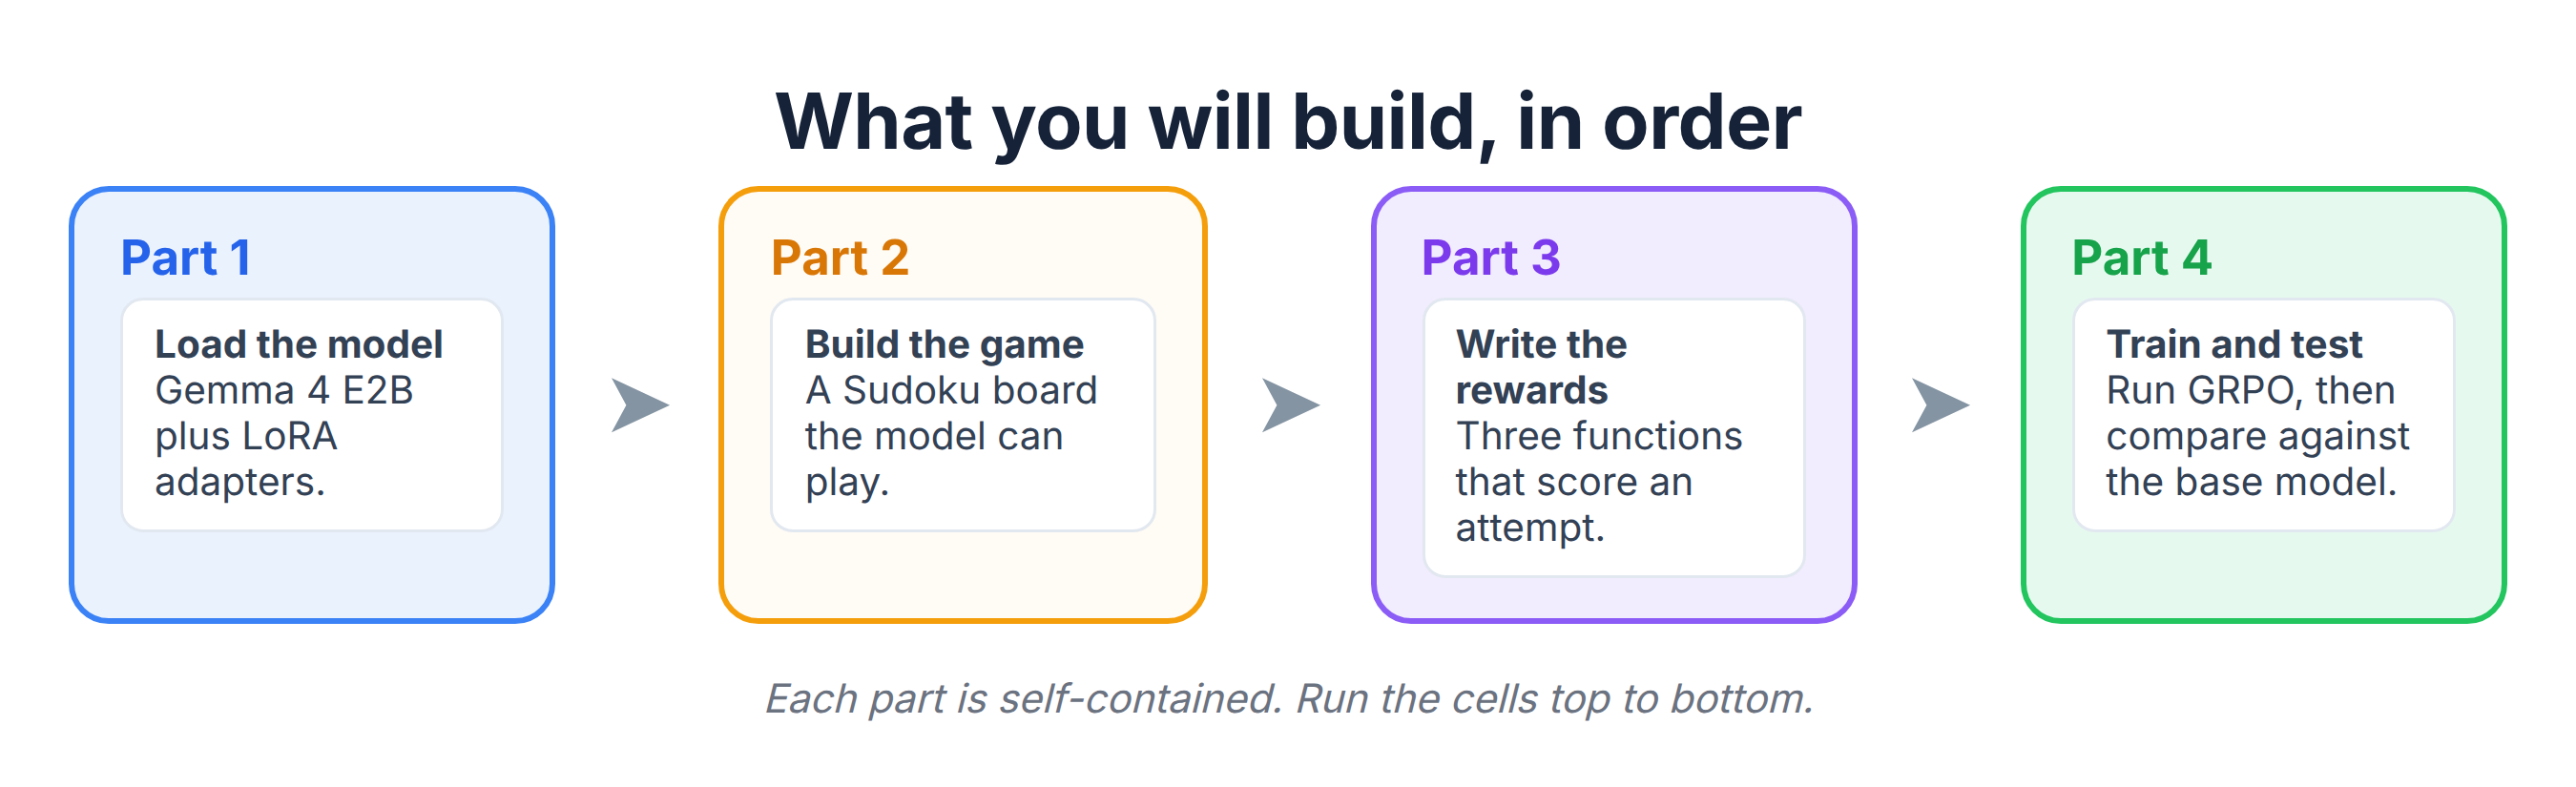

*Run the cells top to bottom.*

---

# Part 0: The ideas, in plain English

Read this section once before running anything. It is short, and it makes every
later cell obvious instead of mysterious.

## What problem are we actually solving?

A pre-trained language model like Gemma 4 is a generalist. It has read an
enormous amount of text and can chat, summarize, and write code. What it has
*not* done is practise a specific task against real feedback.

Our task is deliberately concrete and easy to check:

> Write a Python function `strategy(board, initial)` that looks at a Sudoku
> board and returns the next move as `(row, col, number)`.

Why this task? Because we can **verify** it mechanically. We do not need a human
to judge whether an answer is good. We can take the function the model wrote,
run it on a real puzzle, and count how many legal moves it makes. That
verifiability is exactly what makes a task suitable for reinforcement learning.

### A quick refresher on Sudoku

Fill a 9x9 grid so that every **row**, every **column**, and every **3x3 box**
contains the digits 1 to 9 exactly once. The puzzle starts with some cells
already filled, and those given cells are fixed.

In the completed grid below, the **black digits are the givens** the puzzle
started with, and the **red digits are the moves** needed to finish it. That
distinction is exactly the one our code makes: `initial` is the black digits,
which a strategy must never overwrite, and `board` is the grid as it stands
right now. Every red digit is one call to `place_number(row, col, num)`, and it
is only legal if it breaks none of the three rules above.

<img alt="A completed 9x9 Sudoku grid where the black digits are the puzzle's original given clues and the red digits are the moves added to solve it" src="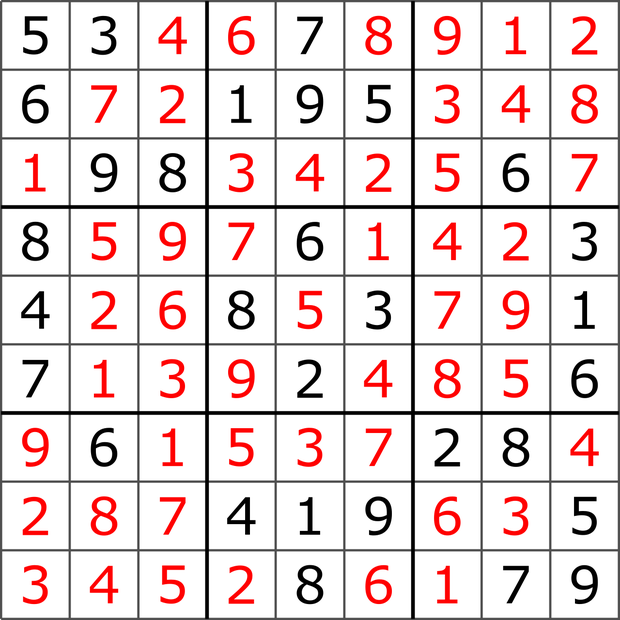" width="36%">

*A solved puzzle. Black digits are the givens (`initial`), red digits are the placed moves. Image by [Cburnett](https://commons.wikimedia.org/wiki/File:Sudoku_Puzzle_by_L2G-20050714_solution_standardized_layout.svg), [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).*

## Supervised fine-tuning versus reinforcement learning

There are two broad ways to teach a model something new.

**Supervised fine-tuning (SFT)** is imitation. You collect examples of the right
answer and the model learns to copy them. It is the workhorse of fine-tuning and
where most projects start. Its cost is that *you* have to produce a correct
answer for every training example.

**Reinforcement learning (RL)** is practice. You do not supply the answer. You
supply a way to **score** an answer. The model generates attempts, each attempt
is scored, and the model is nudged toward whatever scores well.

For our Sudoku task, RL is the natural fit. Writing hundreds of correct,
diverse Sudoku solvers by hand would be painful. Writing a function that checks
whether a solver works is easy.

<img alt="Supervised fine-tuning copies a human-written gold answer, while GRPO lets the model write several attempts and rewards the ones that score best" src="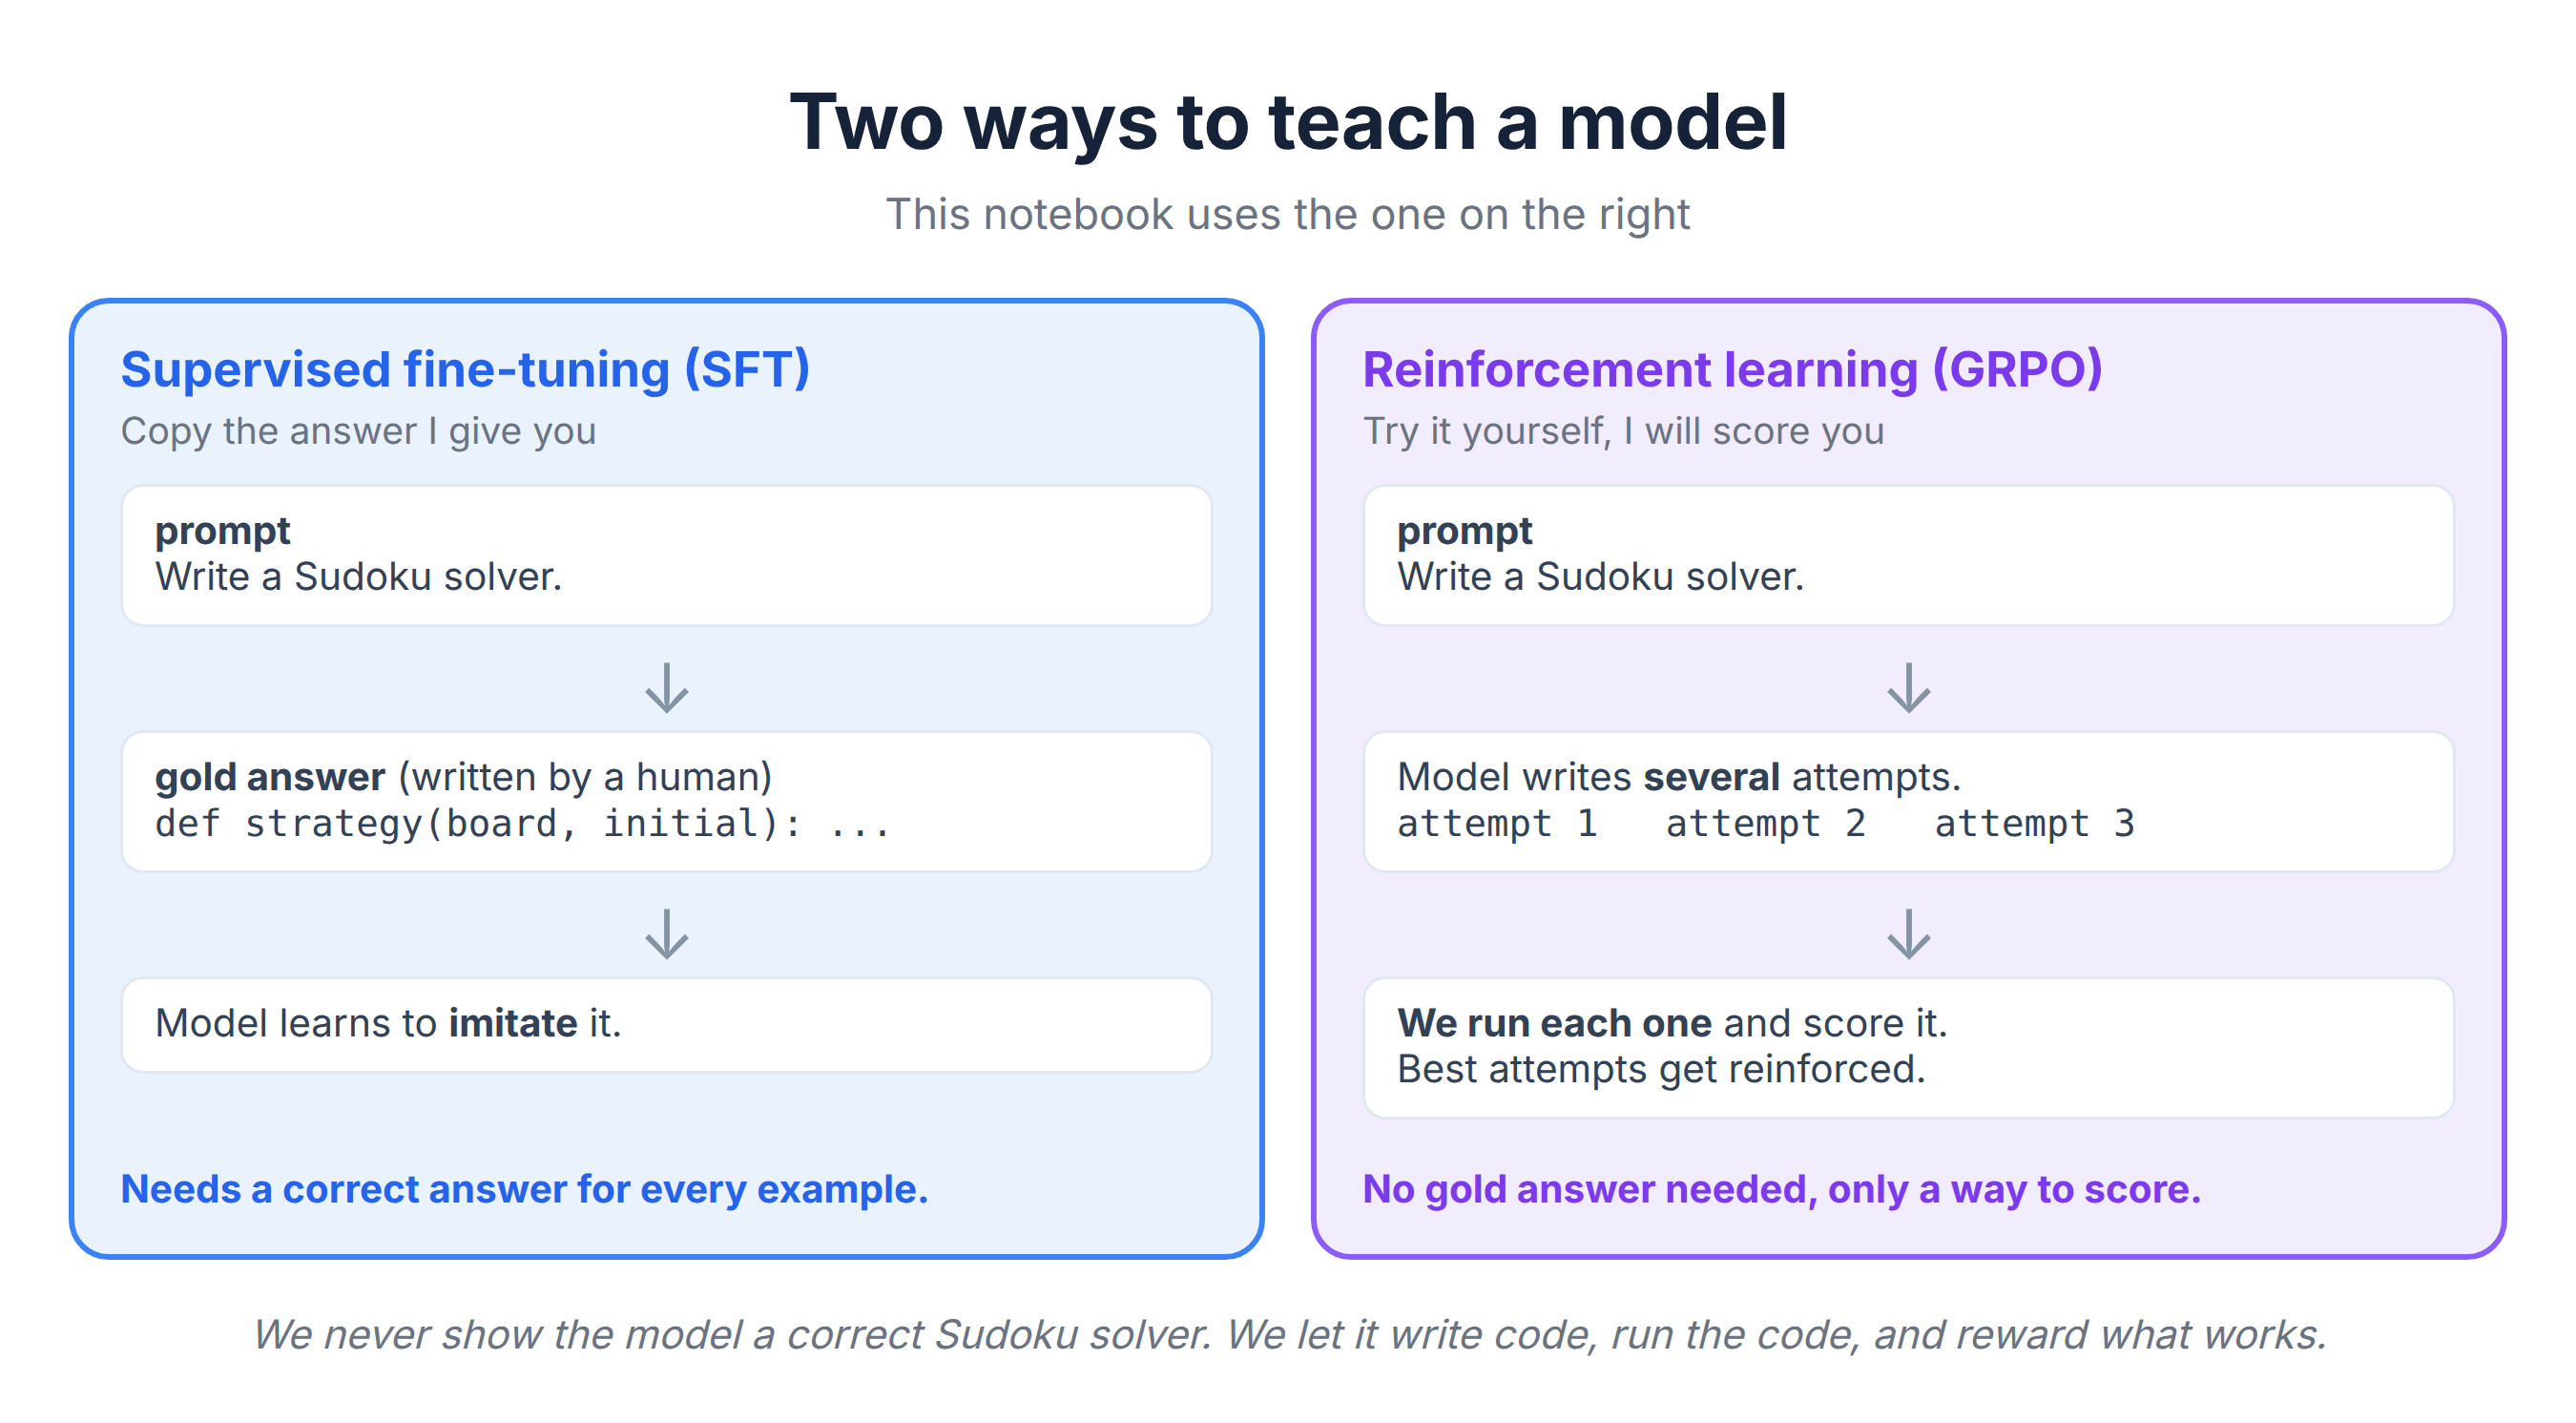" width="100%">

*We never show the model a correct solver. It writes code, we run the code, and we reward what works.*

## What is GRPO?

**GRPO** stands for **Group Relative Policy Optimization**. It is a modern,
memory-efficient RL algorithm, popularized by the DeepSeek reasoning work, and
it is particularly good at teaching models to *reason*.

The name describes the mechanism, so it is worth unpacking:

- **Group.** For a single prompt, the model generates a **group** of different
  candidate answers, not just one.
- **Relative.** Each candidate is scored, and then judged **relative to the
  other candidates in its own group**. A candidate that scores above the group
  average is reinforced; one below the average is discouraged.
- **Policy Optimization.** The "policy" is just the model's behavior. We
  optimize it by shifting it toward the better candidates.

The elegance is in "relative". Older RL methods need a second neural network (a
value model or critic) to estimate how good an answer *should* be, which costs
memory and complexity. GRPO throws that away and uses the group average as the
baseline instead. Fewer moving parts, less memory, which is precisely why this
workshop fits on one GPU.

<img alt="The four stages of one GRPO step: generate a group of candidates, score each with the reward functions, compare scores within the group, then update the LoRA adapters toward the above-average candidates" src="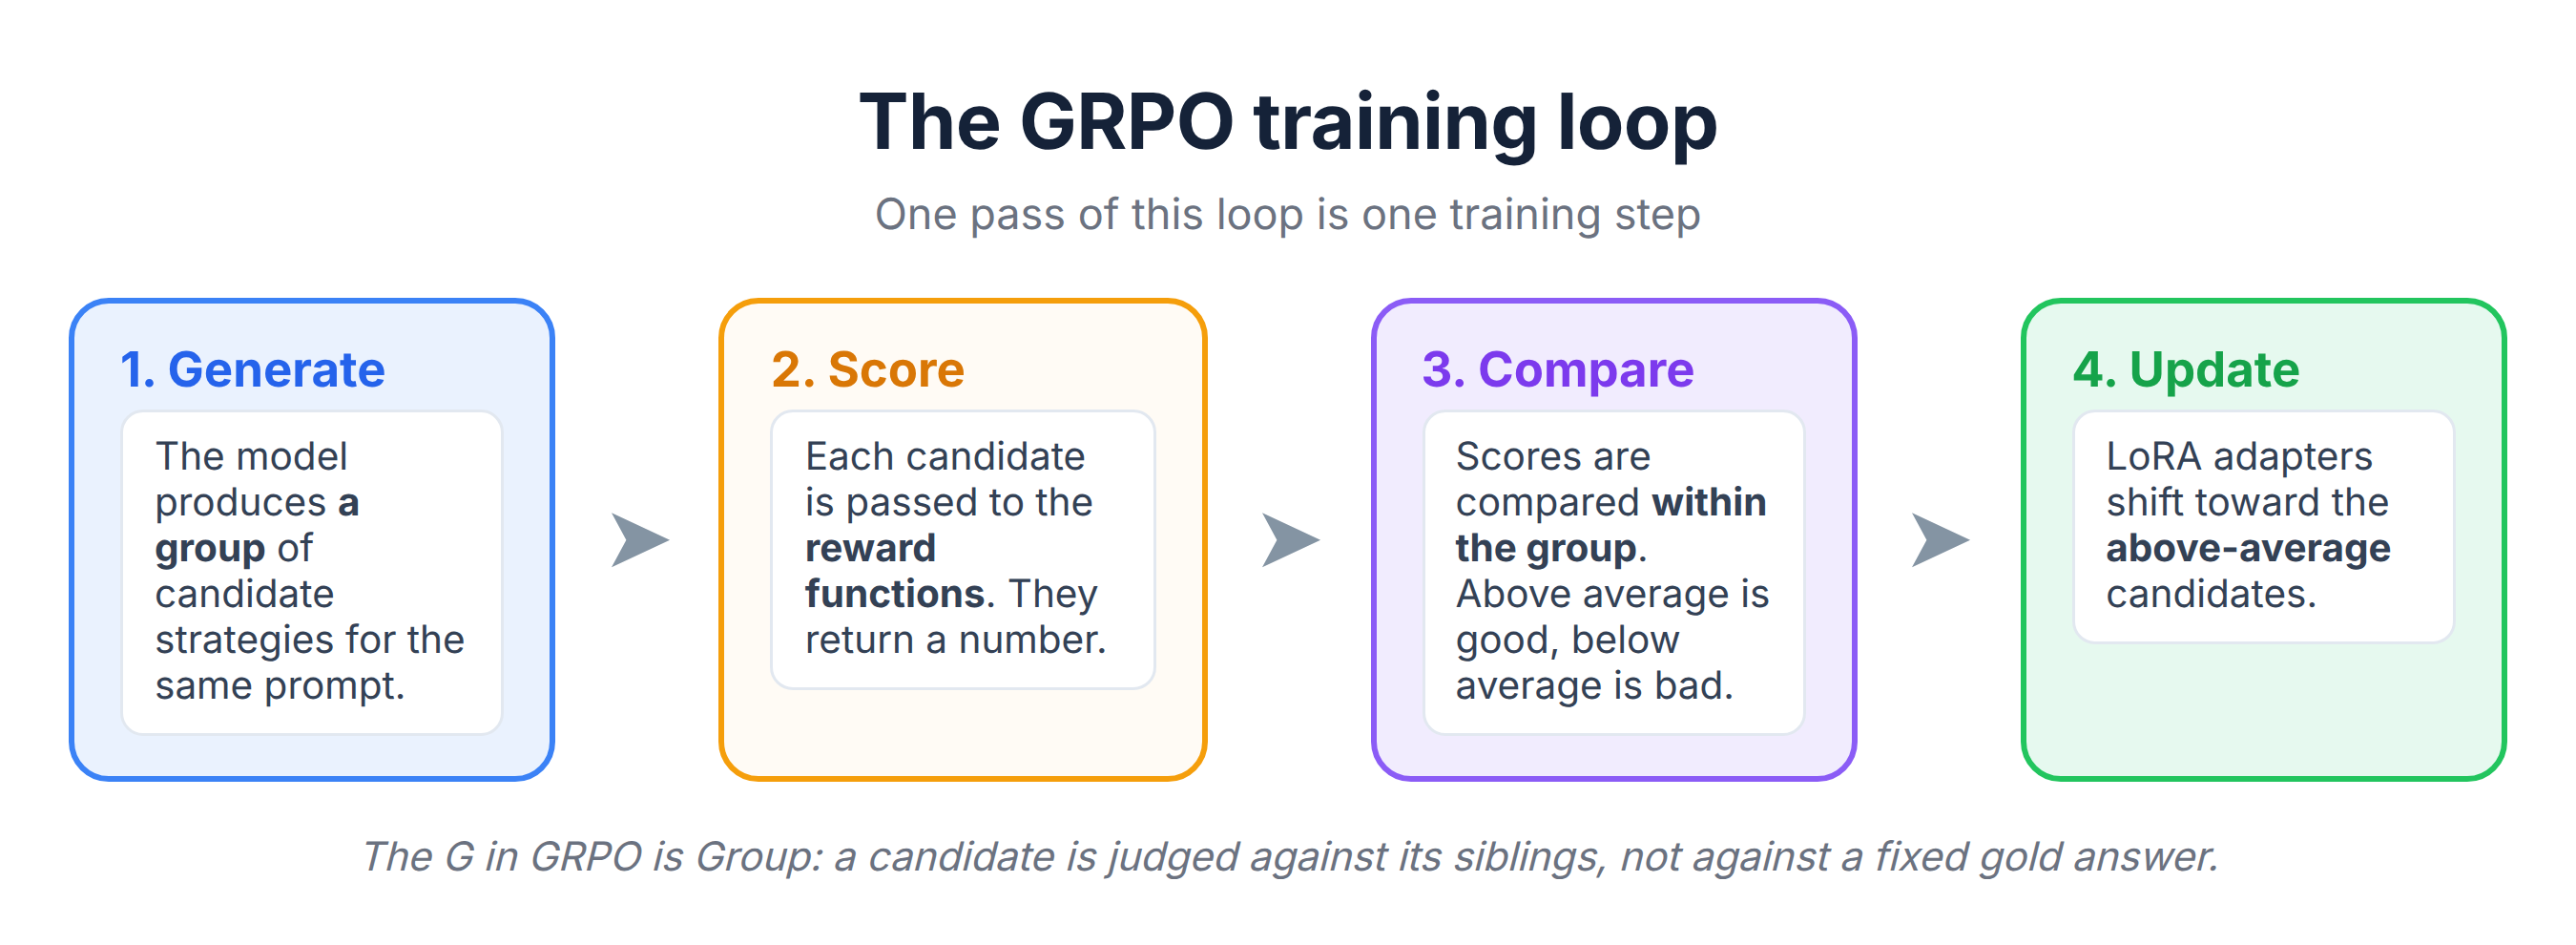" width="100%">

*One pass of this loop is one training step.*

## Reward functions: where you do the real work

In supervised fine-tuning, your effort goes into the dataset. In reinforcement
learning, your effort goes into the **reward function**. It is the single most
important design decision in this notebook, because it is the only thing that
defines what "better" means.

You will write three of them, and they stack:

1. **`function_works`** rewards output that is valid, runnable Python defining a
   `strategy` function. Without this, the model has no incentive to produce
   parseable code at all.
2. **`no_cheating`** penalizes the model for importing libraries. It must solve
   the puzzle with plain Python.
3. **`strategy_succeeds`** is the real objective. We execute the generated
   function against an actual Sudoku puzzle and score it by how many legal moves
   it makes, with a large bonus for solving the puzzle outright.

Rewards 1 and 2 are guardrails. Reward 3 is the goal. The total score for an
attempt is the sum of all three.

<img alt="Three reward functions: function_works checks the code compiles, no_cheating penalizes imports, and strategy_succeeds runs the strategy on a real puzzle and scores the legal moves it makes" src="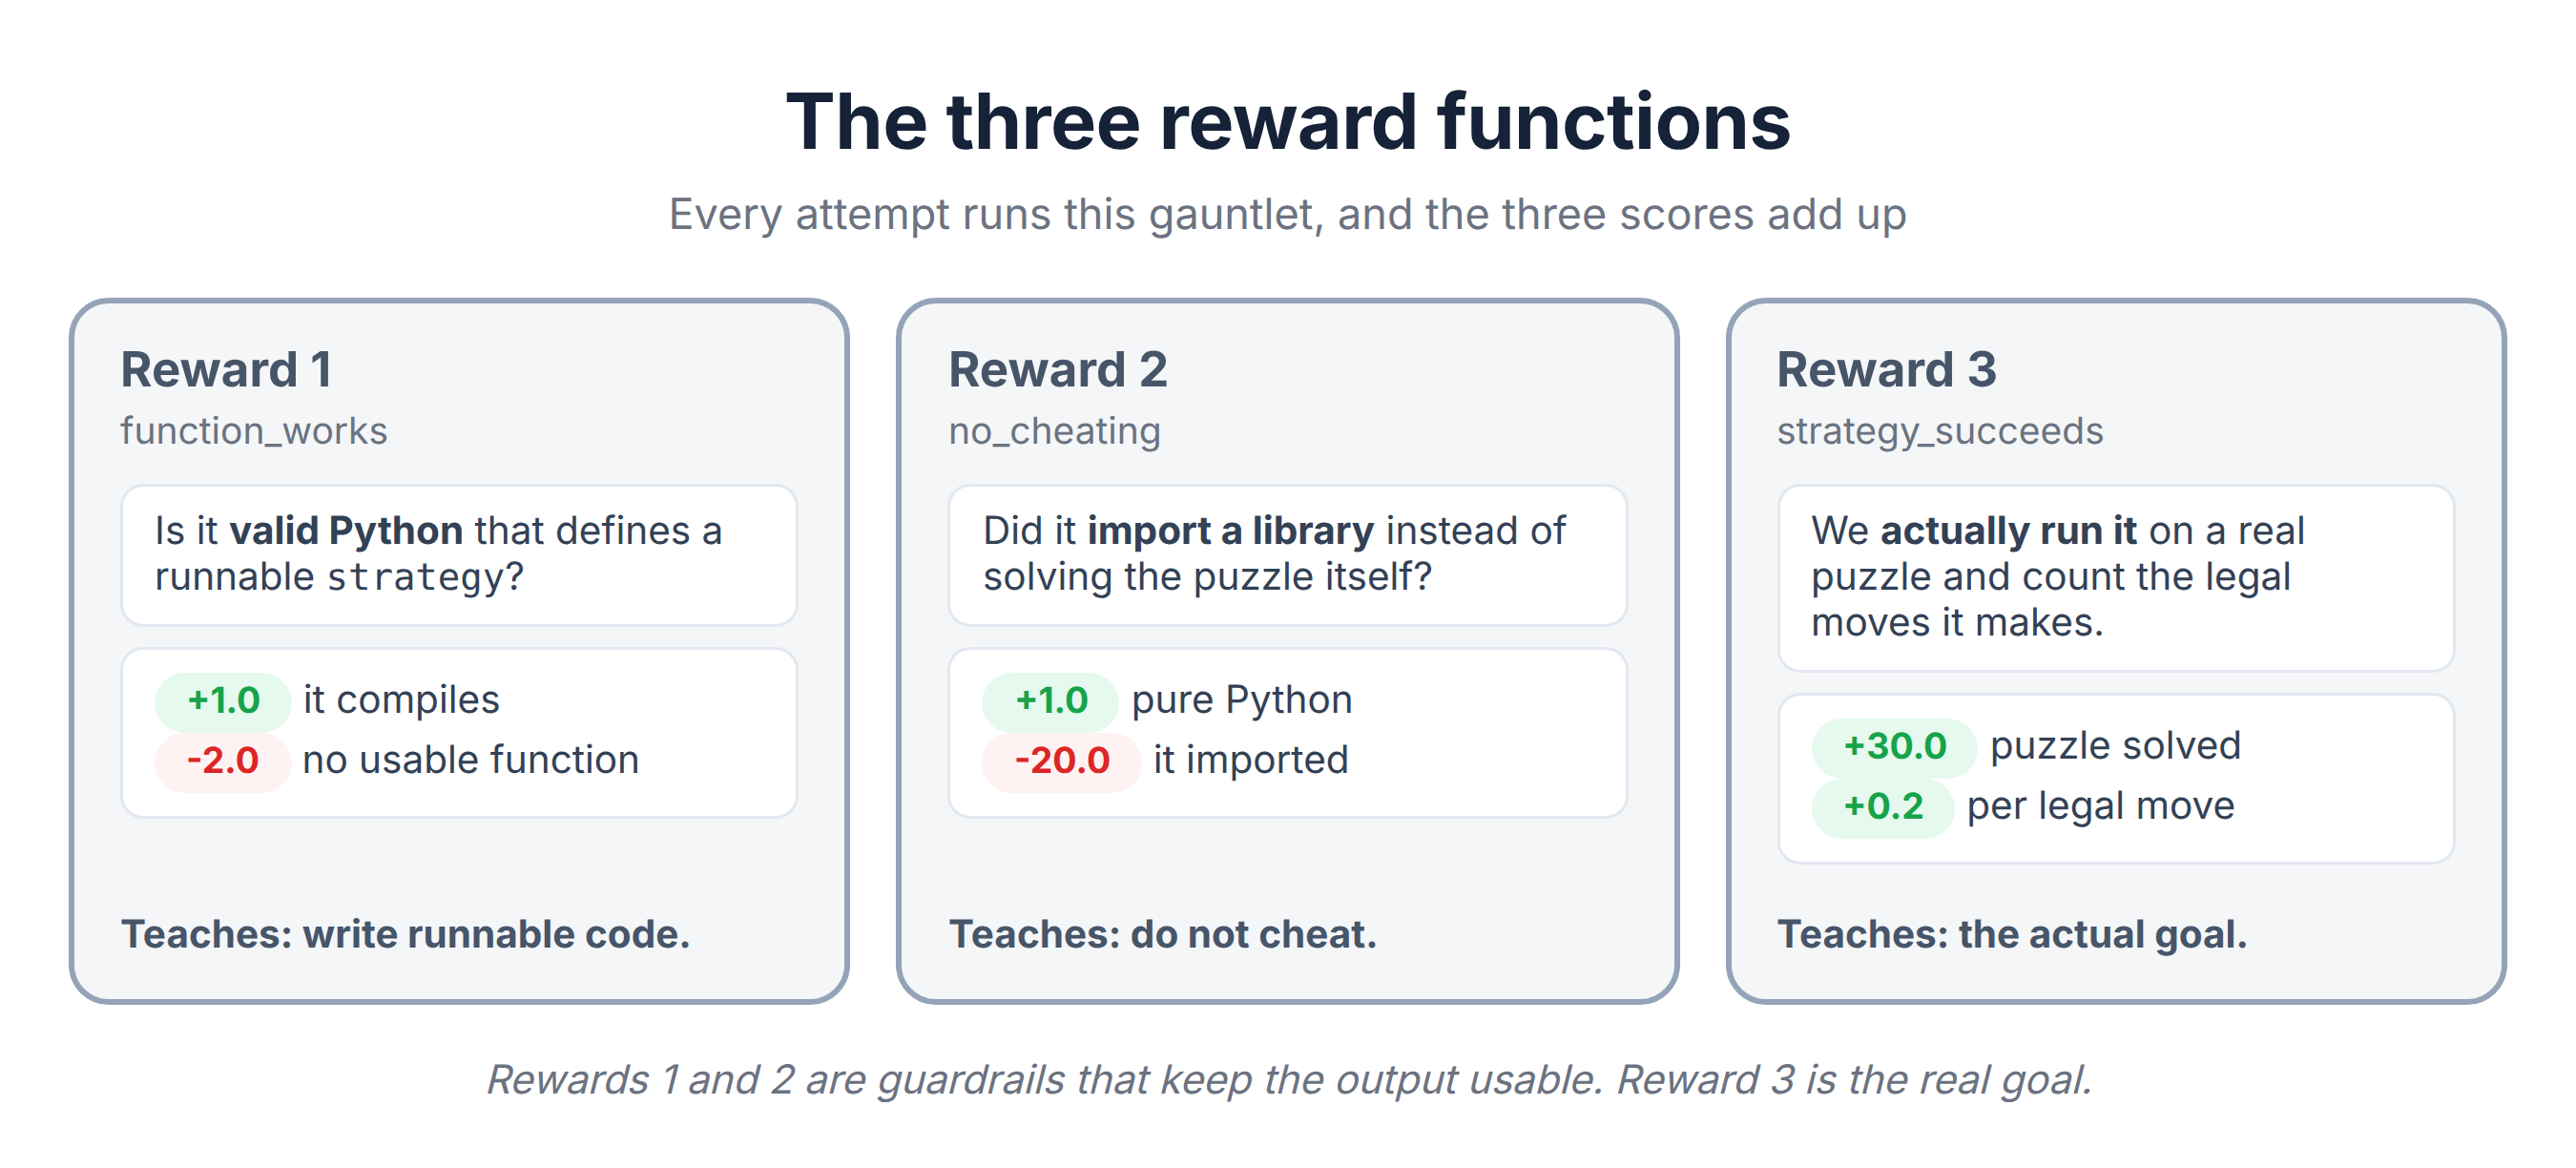" width="100%">

*Guardrails first, then the goal.*

## Reward hacking, and why we run code in a sandbox

Here is the lesson that surprises people new to RL:

> **A model optimizes the reward you wrote, not the goal you meant.**

If there is a cheap shortcut to a high score, the model will find it. This is
called **reward hacking**, and it is not the model misbehaving. It is the model
doing exactly what you asked, revealing that you asked for the wrong thing.

For our task, the obvious shortcut is to `import` a Sudoku solver, or reach out
to something else in the notebook that already knows the answer. The generated
function would score beautifully on "did the puzzle get solved" while the model
learned nothing about solving Sudoku.

So before we ever execute model-written code, we run it through guards that
Unsloth provides:

- **`check_python_modules`** inspects the code and tells us whether it imports
  anything outside the allowed set. Our `no_cheating` reward turns that into a
  penalty.
- **`create_locked_down_function`** compiles the function in a restricted
  namespace so it cannot reach the notebook's global variables.
- **`execute_with_time_limit`** caps how long a strategy may run, so an infinite
  loop costs us a few seconds instead of hanging training forever.

There is a second reason for the sandbox that has nothing to do with cheating:
we are about to execute code that a language model wrote, automatically,
hundreds of times. Running that unguarded is a bad idea regardless.

<img alt="Without a sandbox the model can import an external solver and score highly without learning; with import blocking, a time limit and a locked-down function the only way to score is to solve the puzzle" src="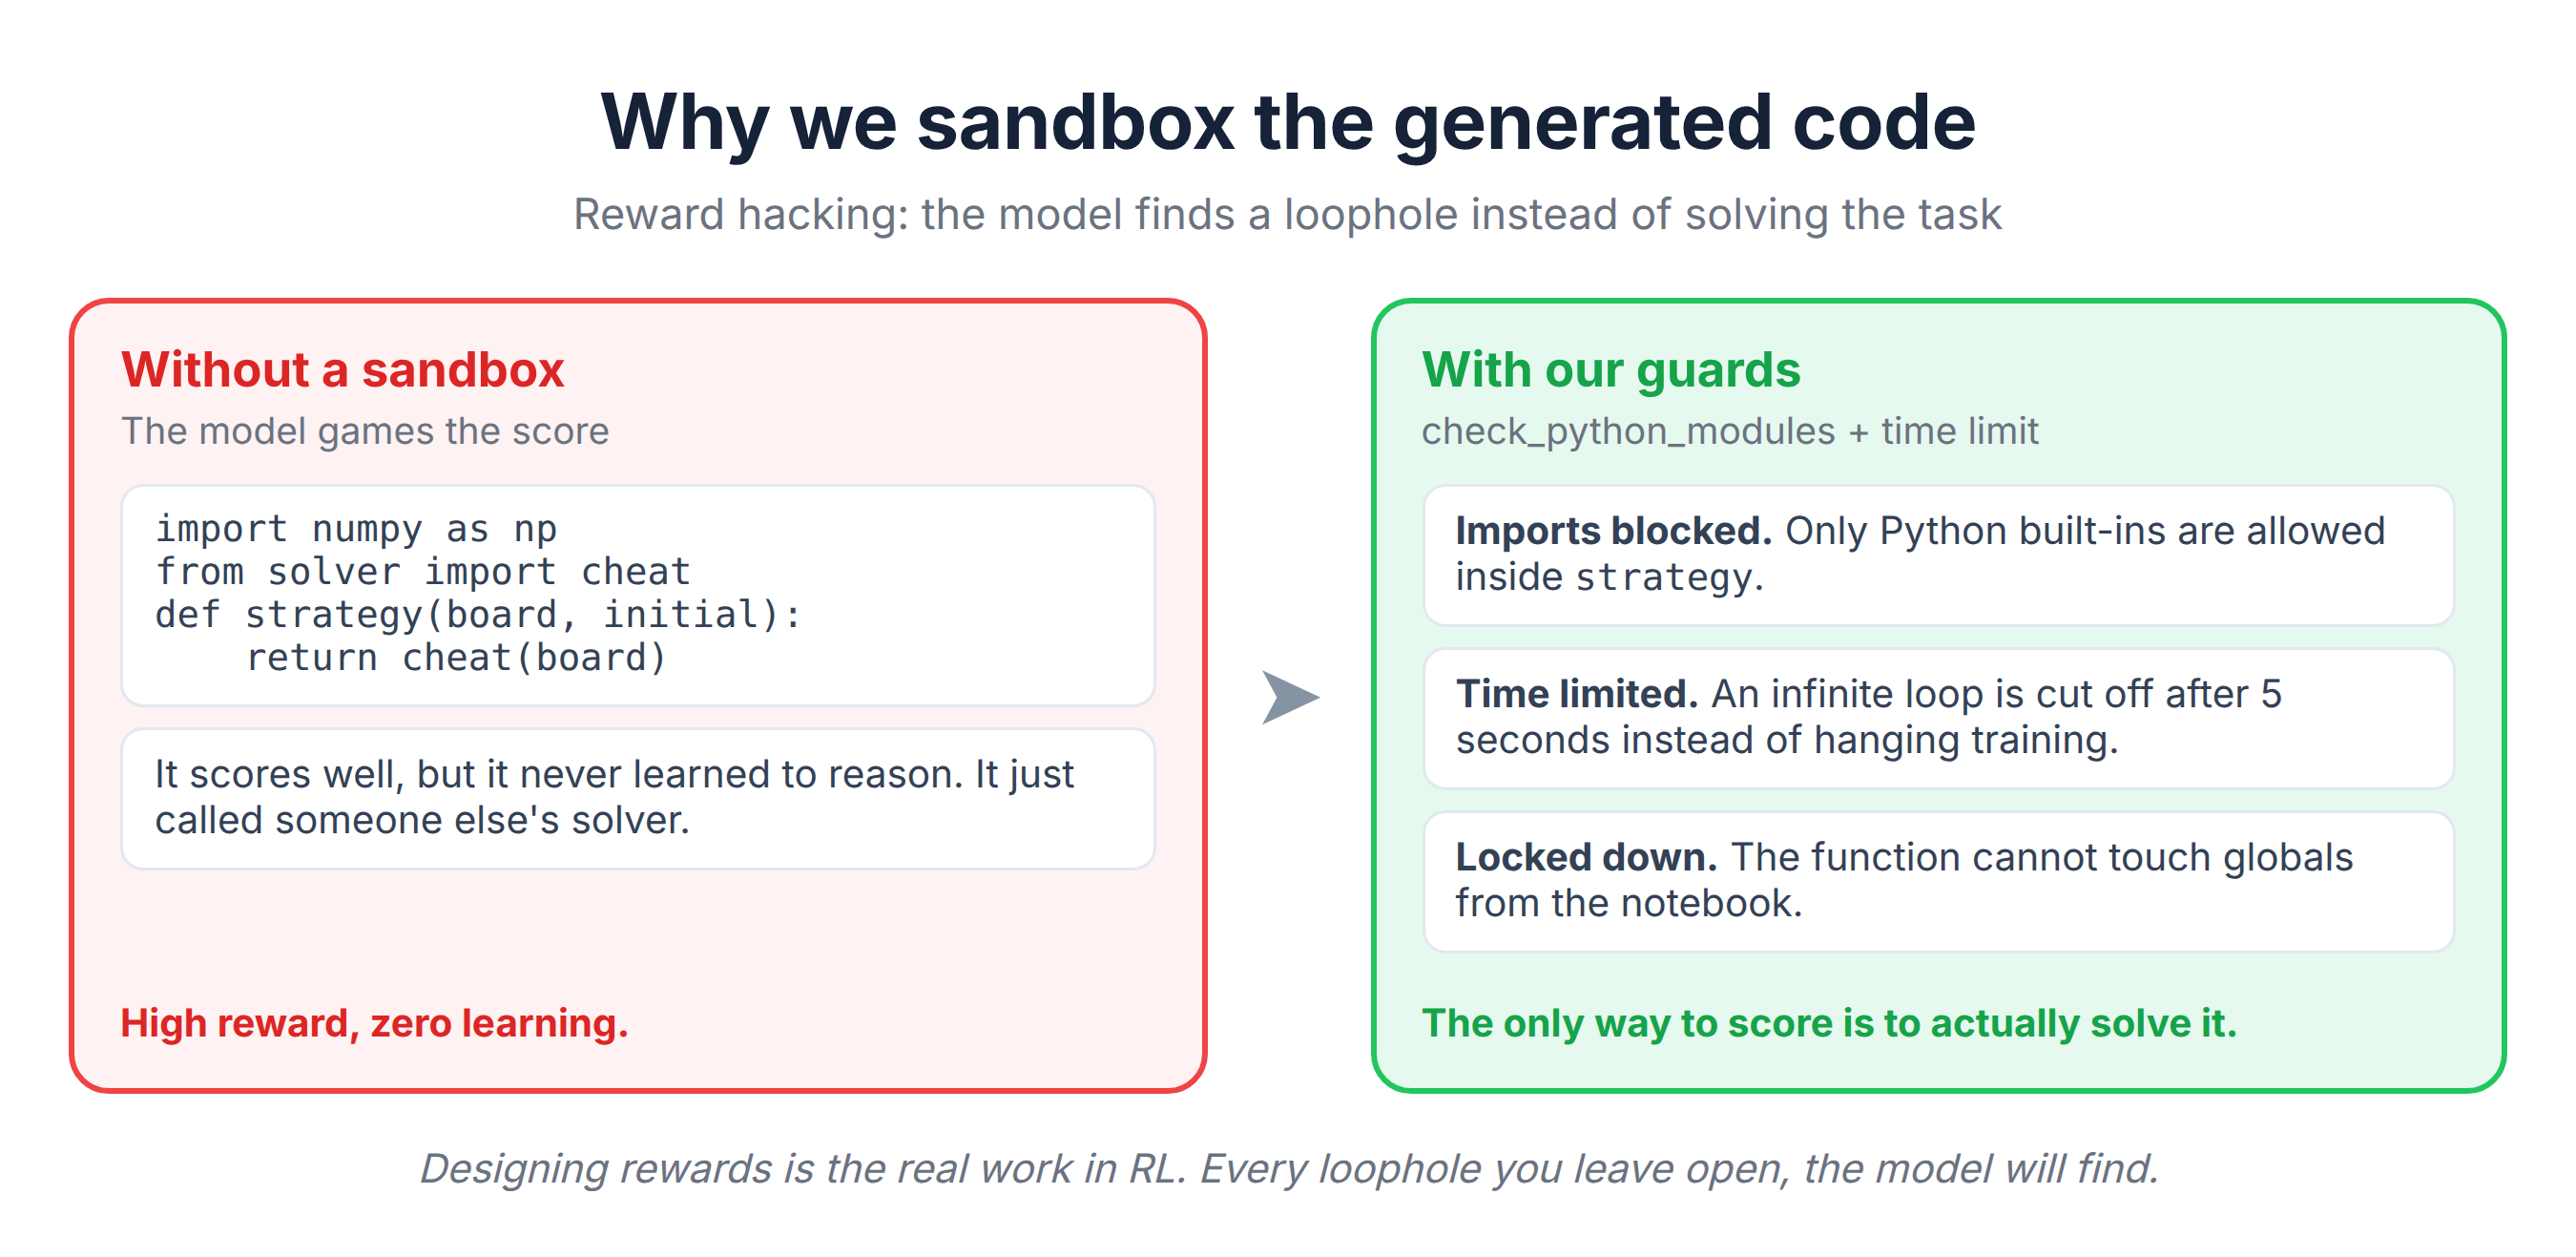" width="100%">

*Every loophole you leave open, the model will find.*

## LoRA: why this fits on one GPU

Gemma 4 has billions of parameters. Updating all of them during training would
require storing gradients and optimizer state for every one, which is far beyond
a single GPU.

**LoRA (Low-Rank Adaptation)** sidesteps this. It **freezes** the original model
weights and injects small trainable "adapter" matrices into selected layers.
Only the adapters train, typically 1 to 2 percent of the parameters. You get
most of the quality of full fine-tuning for a small fraction of the memory, and
the result is a compact adapter file you can share and load on top of the base
model.

That is the setting used below: `lora_rank = 32`, adapters on the attention
projections (`q_proj`, `k_proj`, `v_proj`, `o_proj`) and the MLP projections
(`gate_proj`, `up_proj`, `down_proj`).

**Unsloth** is what makes this fast. It supplies hand-optimized kernels for the
training path, which cuts memory use substantially and speeds up training with
no loss in accuracy, on AMD GPUs included.

<img alt="Full fine-tuning updates every weight and needs large GPUs, while LoRA freezes the base model and trains small adapter matrices instead" src="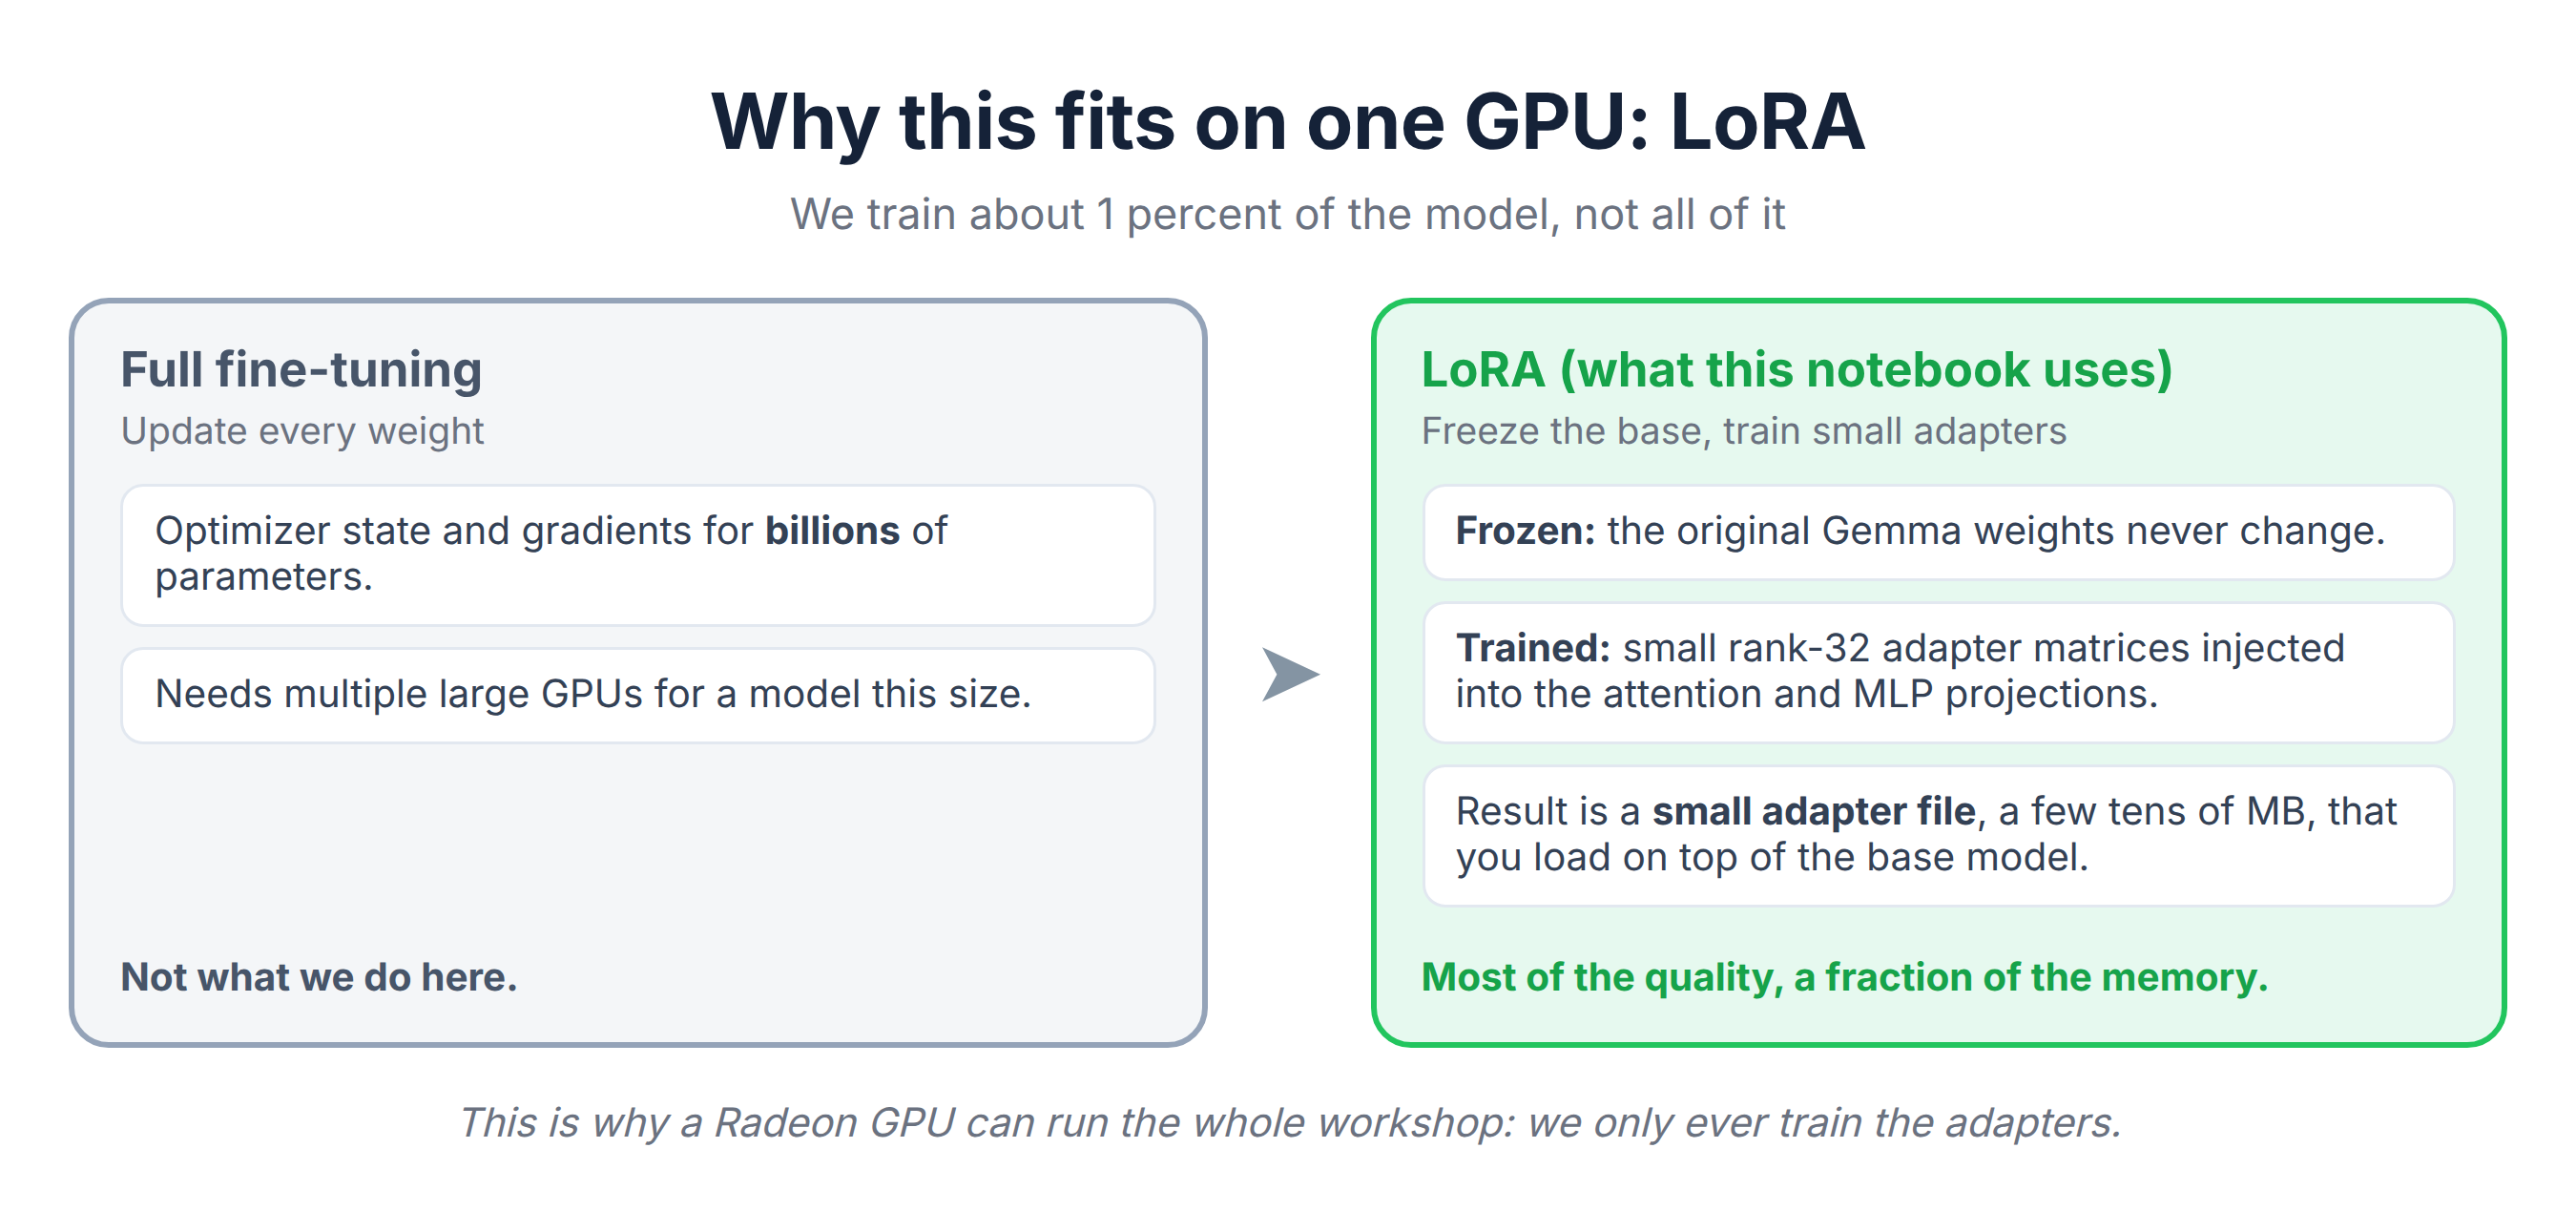" width="100%">

*This is why the whole workshop fits on a single GPU.*

### Vocabulary recap

Keep these five terms in mind and the rest of the notebook reads easily.

| Term | What it means here |
| --- | --- |
| **Policy** | The model itself, viewed as "the thing that chooses outputs". |
| **Completion** | One answer the model generated for a prompt. |
| **Group** | The several completions generated for the *same* prompt, compared against each other. |
| **Reward** | A number scoring one completion. Higher is better. We sum three of them. |
| **Step** | One full pass of generate, score, compare, update. |

---

# Part 1: Setup and the model

## Installation

This workshop image **already has Unsloth installed**, so you can skip the
install block below. It is included for reference, for when you set this up on
your own machine.

To install Unsloth on your own device, follow
[the official guide](https://unsloth.ai/docs/get-started/install).
This notebook is licensed
[LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

> **Reference only, do not run on the workshop image.**

```python
import os, importlib.util

!pip install --upgrade -qqq uv
!pip install bitsandbytes
!pip install cut-cross-entropy torchao --no-deps

# Install unsloth and unsloth-zoo without dependencies
!pip install --no-deps unsloth unsloth-zoo
!pip install --no-deps git+https://github.com/unslothai/unsloth-zoo.git

# Install unsloth with AMD support directly from GitHub
!pip install "unsloth[amd] @ git+https://github.com/unslothai/unsloth"

# Gemma 4 requires transformers >= 5.5.0
!pip install --upgrade --no-deps "transformers>=5.5.0" tokenizers "trl>=0.28.0" unsloth unsloth_zoo
!pip install --no-deps huggingface_hub==1.10.2
```

The one package we do install is `timm`, which Gemma 4 needs for its vision and
audio components.

In [ ]:
%%capture
!pip install --no-deps --upgrade timm # For Gemma 4 vision/audio

## Load Gemma 4 and attach LoRA adapters

Two things happen here.

First, `FastVisionModel.from_pretrained` loads **Gemma 4 E2B Instruct**. Gemma 4
is a multimodal family, which is why the loader is the vision-capable one, but we
only use its text abilities. Other sizes in the family are listed in the cell if
you want to experiment later.

Key settings and why they are set this way:

- `max_seq_length = 4096` gives the model room to write a full strategy function
  and reason on the way there.
- `lora_rank = 32` is the capacity of the adapters. Larger is more expressive but
  slower to train.
- `load_in_4bit = False` keeps the base model in 16-bit, which is the right
  choice when memory allows: LoRA on a 16-bit base trains more stably.

In [ ]:
from unsloth import FastVisionModel
import torch
max_seq_length = 4096 # Can increase for longer reasoning traces
lora_rank = 32 # Larger rank = smarter, but slower

gemma4_models = [
    # Gemma-4 instruct models:
    "unsloth/gemma-4-E2B-it",
    "unsloth/gemma-4-E4B-it",
    #"unsloth/gemma-4-31B-it",
    #"unsloth/gemma-4-26B-A4B-it",
    # Gemma-4 base models:
    "unsloth/gemma-4-E2B",
    "unsloth/gemma-4-E4B",
    #"unsloth/gemma-4-31B",
    "unsloth/gemma-4-26B-A4B",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "/models/unsloth/gemma-4-E2B-it",
    max_seq_length = max_seq_length,
    load_in_4bit = False, # False for LoRA 16bit
    fast_inference = False, # Enable vLLM fast inference
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.4.4: Fast Gemma4 patching. Transformers: 5.5.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

Now we attach the LoRA adapters. `get_peft_model` wraps the frozen base model
with the small trainable matrices described in Part 0.

Note `lora_alpha = lora_rank * 2`. Alpha scales the adapter's contribution;
setting it to twice the rank is a well-tested default that speeds up learning.
`use_gradient_checkpointing = "unsloth"` trades a little compute for a large
memory saving, which is what lets the sequence length stay at 4096.

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha = lora_rank*2, # *2 speeds up training
    use_gradient_checkpointing = "unsloth", # Reduces memory usage
    random_state = 3407,
)
model.config._attn_implementation = "sdpa" # Use this to disable flash attention to avoid OOM

---

# Part 2: The Sudoku environment

Before we can reward the model, we need something for it to act on. In RL terms
this is the **environment**: the world the policy interacts with and the thing
that tells us whether an action was legal.

Our environment is a Sudoku game with a deliberately small interface:

- `board()` returns the current 9x9 grid, where `0` means empty.
- `initial_board()` returns the starting puzzle, so a strategy can tell which
  cells were given and must not be touched.
- `place_number(row, col, num)` attempts a move and returns whether it was legal.
- `state()` reports `ongoing`, `success`, or `failed`.

A move is legal only if the cell is empty in both the current and the initial
board, and the digit does not already appear in that row, column, or 3x3 box.
One illegal move ends the game. That strictness matters: it means a strategy
cannot stumble to a solution by guessing.

In [ ]:
#@title Sudoku Game Implementation
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import random
import copy

def _is_valid_placement(board: List[List[int]], row: int, col: int, num: int) -> bool:
    """Check if placing num at (row, col) is valid."""
    # Check row
    if num in board[row]:
        return False

    # Check column
    if num in [board[r][col] for r in range(9)]:
        return False

    # Check 3x3 box
    box_row, box_col = 3 * (row // 3), 3 * (col // 3)
    for r in range(box_row, box_row + 3):
        for c in range(box_col, box_col + 3):
            if board[r][c] == num:
                return False

    return True

def _solve_sudoku(board: List[List[int]]) -> bool:
    """Solve sudoku using backtracking (for puzzle generation)."""
    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:
                for num in range(1, 10):
                    if _is_valid_placement(board, row, col, num):
                        board[row][col] = num
                        if _solve_sudoku(board):
                            return True
                        board[row][col] = 0
                return False
    return True

def _generate_complete_board(rng: random.Random) -> List[List[int]]:
    """Generate a complete valid Sudoku board."""
    board = [[0 for _ in range(9)] for _ in range(9)]

    # Fill diagonal 3x3 boxes first (they don't affect each other)
    for box in range(3):
        nums = list(range(1, 10))
        rng.shuffle(nums)
        for i in range(3):
            for j in range(3):
                board[box * 3 + i][box * 3 + j] = nums[i * 3 + j]

    # Solve the rest
    _solve_sudoku(board)
    return board

@dataclass
class SudokuGame:
    difficulty: int = 40  # Number of cells to remove (20=easy, 40=medium, 50=hard)
    seed: Optional[int] = None
    _rng: random.Random = field(init=False, repr=False)
    _board: List[List[int]] = field(init=False, repr=False)
    _solution: List[List[int]] = field(init=False, repr=False)
    _initial_board: List[List[int]] = field(init=False, repr=False)
    _moves: int = field(default=0, init=False, repr=False)
    _state: str = field(default="ongoing", init=False, repr=False)

    def __post_init__(self):
        self._rng = random.Random(self.seed)

        # Generate complete board
        complete_board = _generate_complete_board(self._rng)
        self._solution = copy.deepcopy(complete_board)

        # Remove cells to create puzzle
        self._board = copy.deepcopy(complete_board)
        cells = [(r, c) for r in range(9) for c in range(9)]
        self._rng.shuffle(cells)

        for r, c in cells[:self.difficulty]:
            self._board[r][c] = 0

        self._initial_board = copy.deepcopy(self._board)
        self._update_state()

    def board(self) -> List[List[int]]:
        """Return current board state."""
        return [row[:] for row in self._board]

    def initial_board(self) -> List[List[int]]:
        """Return initial puzzle state."""
        return [row[:] for row in self._initial_board]

    def state(self) -> str:
        """Return game state: 'ongoing', 'success', or 'failed'."""
        return self._state

    def moves(self) -> int:
        """Return number of moves made."""
        return self._moves

    def place_number(self, row: int, col: int, num: int) -> bool:
        """Place a number on the board. Returns True if valid move."""
        # Validate input
        if not (0 <= row < 9 and 0 <= col < 9):
            self._state = "failed"
            return False

        if not (1 <= num <= 9):
            self._state = "failed"
            return False

        # Can't modify initial cells
        if self._initial_board[row][col] != 0:
            self._state = "failed"
            return False
        if self._board[row][col] != 0:
            self._state = "failed"
            return False
        # Check if placement is valid
        if not _is_valid_placement(self._board, row, col, num):
            self._state = "failed"
            return False

        # Place number
        self._board[row][col] = num
        self._moves += 1
        self._update_state()
        return True

    def _update_state(self) -> None:
        """Update game state based on current board."""
        # Check if puzzle is complete
        if all(self._board[r][c] != 0 for r in range(9) for c in range(9)):
            # Verify solution is correct
            if self._board == self._solution:
                self._state = "success"
            else:
                self._state = "failed"
        else:
            self._state = "ongoing"

    def pretty(self, colors: bool = True) -> str:
        """Pretty print the Sudoku board."""
        RESET = "\x1b[0m"
        INITIAL = "\x1b[38;5;45m"   # Cyan for initial numbers
        PLACED = "\x1b[38;5;196m"    # Red for placed numbers
        EMPTY = "\x1b[38;5;239m"     # Gray for empty cells

        lines = []
        lines.append("┌───────┬───────┬───────┐")

        for row in range(9):
            row_str = "│ "
            for col in range(9):
                num = self._board[row][col]

                if colors:
                    if num == 0:
                        row_str += f"{EMPTY}.{RESET}"
                    elif self._initial_board[row][col] != 0:
                        row_str += f"{INITIAL}{num}{RESET}"
                    else:
                        row_str += f"{PLACED}{num}{RESET}"
                else:
                    row_str += str(num) if num != 0 else "."

                if col % 3 == 2:
                    row_str += " │ "
                else:
                    row_str += " "

            lines.append(row_str.rstrip())

            if row == 8:
                lines.append("└───────┴───────┴───────┘")
            elif row % 3 == 2:
                lines.append("├───────┼───────┼───────┤")

        return "\n".join(lines)

Let us create a puzzle and look at it.

In [ ]:
# Create an easy puzzle
game = SudokuGame(difficulty=30, seed=42)
print("Initial puzzle:")
print(game.pretty())
print(f"\nState: {game.state()}, Moves: {game.moves()}")

Initial puzzle:
┌───────┬───────┬───────┐
│ 4 . 8 │ . 5 2 │ 6 3 . │
│ . 9 3 │ 4 6 7 │ . . 1 │
│ 6 1 2 │ . 9 8 │ 4 . . │
├───────┼───────┼───────┤
│ 1 . 4 │ . . . │ 7 9 5 │
│ 3 . 9 │ 7 1 . │ 8 2 6 │
│ 7 8 . │ 5 . 9 │ 1 . 3 │
├───────┼───────┼───────┤
│ 2 4 . │ 9 7 . │ . 6 . │
│ 8 3 5 │ 6 4 . │ . 7 . │
│ . . 7 │ 2 . . │ . 1 4 │
└───────┴───────┴───────┘

State: ongoing, Moves: 0


In [ ]:
game

SudokuGame(difficulty=30, seed=42)

Now try a move. `place_number` returns `True` when the move was accepted.

In [ ]:
# Make a valid move
game.place_number(0, 1, 7)
print("\nAfter placing 7 at (1,0):")
print(game.pretty())
print(f"State: {game.state()}, Moves: {game.moves()}")


After placing 7 at (1,0):
┌───────┬───────┬───────┐
│ 4 7 8 │ . 5 2 │ 6 3 . │
│ . 9 3 │ 4 6 7 │ . . 1 │
│ 6 1 2 │ . 9 8 │ 4 . . │
├───────┼───────┼───────┤
│ 1 . 4 │ . . . │ 7 9 5 │
│ 3 . 9 │ 7 1 . │ 8 2 6 │
│ 7 8 . │ 5 . 9 │ 1 . 3 │
├───────┼───────┼───────┤
│ 2 4 . │ 9 7 . │ . 6 . │
│ 8 3 5 │ 6 4 . │ . 7 . │
│ . . 7 │ 2 . . │ . 1 4 │
└───────┴───────┴───────┘
State: ongoing, Moves: 1


If we attempt a move outside the action space, or one that breaks a Sudoku rule,
the move is rejected and the game stops accepting further actions. This is the
signal our reward function will ultimately measure.

---

# Part 3: Running model-written code safely

We now build the harness that takes a strategy function and plays it against a
game. This is the piece that turns "the model wrote some code" into "the code
scored 7.4".

`_execute_strategy` loops: ask the strategy for a move, validate the shape of
what came back, attempt the move, repeat. It stops on the first illegal move or
malformed return, and it caps the loop at 100 moves so a strategy that returns
the same move forever cannot spin.

Crucially it returns **both** the number of valid moves made and the final game
state. Partial credit matters in RL: a strategy that makes 12 legal moves before
failing is genuinely better than one that fails immediately, and the reward
should say so.

In [ ]:
from typing import Callable
from unsloth import execute_with_time_limit

def _execute_strategy(strategy: Callable, game: SudokuGame):
    """Execute a strategy function on a Sudoku game."""
    assert callable(strategy)

    max_moves = 100
    valid_moves = 0  # Track successful moves

    while game.state() == "ongoing" and valid_moves < max_moves:
        try:
            board = game.board()
            initial = game.initial_board()
            result = strategy(board, initial)

            # Validate result format
            if not isinstance(result, (tuple, list)) or len(result) != 3:
                # Invalid format = immediate fail, but return valid moves made
                return valid_moves, "failed"

            row, col, num = result

            # Validate types
            if not all(isinstance(x, int) for x in [row, col, num]):
                return valid_moves, "failed"

            # Try to place number
            success = game.place_number(row, col, num)

            if success:
                valid_moves += 1  # Count this valid move
            else:
                # Invalid move = game fails, but return valid_moves made so far
                return valid_moves, "failed"

        except Exception:
            return valid_moves, "failed"

    if valid_moves >= max_moves and game.state() == "ongoing":
        return valid_moves, "failed"

    return valid_moves, game.state()

Next we wrap that loop in a time limit. Model-generated code can contain
infinite loops, and without a cap a single bad strategy would stall training.

The original workshop uses 10 seconds to allow more elaborate strategies. We use
**5 seconds** here to keep the session brisk. Raise it if you want to give the
model room for slower, more thorough search.

In [ ]:
@execute_with_time_limit(5)  # Set a time limit of 5 seconds for strategy execution, originally was 10 seconds
def execute_strategy(strategy: Callable, game: SudokuGame):
    """Execute strategy with 10 second time limit."""
    return _execute_strategy(strategy, game)

Let us sanity check the harness with a trivial hand-written strategy, so we know
the machinery works before we hand it model output.

In [ ]:
def simple_strategy(board, initial):
    """Simple strategy: fill first empty cell with 1."""
    for r in range(9):
        for c in range(9):
            if board[r][c] == 0 and initial[r][c] == 0:
                return (r, c, 7)
    return (0, 0, 7)

game = SudokuGame(difficulty=30, seed=42)
try:
    moves, state = execute_strategy(simple_strategy, game)
    print(f"Moves: {moves}, State: {state}")
except TimeoutError as e:
    print(f"Timed out: {e}")

Moves: 1, State: failed


In [ ]:
print(game.pretty())

┌───────┬───────┬───────┐
│ 4 7 8 │ . 5 2 │ 6 3 . │
│ . 9 3 │ 4 6 7 │ . . 1 │
│ 6 1 2 │ . 9 8 │ 4 . . │
├───────┼───────┼───────┤
│ 1 . 4 │ . . . │ 7 9 5 │
│ 3 . 9 │ 7 1 . │ 8 2 6 │
│ 7 8 . │ 5 . 9 │ 1 . 3 │
├───────┼───────┼───────┤
│ 2 4 . │ 9 7 . │ . 6 . │
│ 8 3 5 │ 6 4 . │ . 7 . │
│ . . 7 │ 2 . . │ . 1 4 │
└───────┴───────┴───────┘


## The safety guards

This is the reward-hacking defense from Part 0, in code.

`check_python_modules` inspects a source string and reports whether it stays
inside the allowed set of Python built-ins. `create_locked_down_function`
compiles it in a restricted namespace so it cannot read the notebook's globals.

First, code that plays by the rules. It uses only built-ins, so it passes.

In [ ]:
from unsloth import check_python_modules, create_locked_down_function

# Test safe code
sample = """
def strategy(board, initial):
    for r in range(9):
        for c in range(9):
            if board[r][c] == 0:
                return (r, c, 1)
    return (0, 0, 1)
"""

ok, info = check_python_modules(sample)
print("Safe Python code?", ok)
print(info)

Safe Python code? True
{'stdlib': [], 'non_stdlib': [], 'relative_imports': 0}


And now code that imports `numpy`. This is exactly the shortcut we want to
catch: it should be rejected, and the `no_cheating` reward will turn that
rejection into a penalty.

In [ ]:
sample = """
def strategy(board, initial):
    import numpy as np
    return (0, 0, 1)
"""

ok, info = check_python_modules(sample)
print("Safe Python code?", ok)
print(info)

Safe Python code? False
{'stdlib': [], 'non_stdlib': ['numpy'], 'relative_imports': 0}


---

# Part 4: The prompt and the untrained baseline

The prompt is the task specification. It tells the model the shape of the input,
the shape of the expected output, the rules it must respect, and the format to
answer in (a Python function in triple backticks, which our extractor relies on).

This prompt is also the natural place to start if you want to adapt this notebook
to a different RL task. Change the task described here, change the reward
functions to match, and the rest of the machinery carries over unchanged.

In [ ]:
prompt = """
Create a Sudoku solving strategy using only native Python built-in functions without any import statements.
You are given two lists of lists (9x9 grids):
- board: current state (0 means empty)
- initial: starting puzzle (0 means was empty, numbers are fixed)

Return a tuple (row, col, number) for the next move.
- row: 0-8 (row index)
- col: 0-8 (column index)
- number: 1-9 (digit to place)

Only place numbers in cells that are BOTH empty in initial AND empty in board (initial[row][col] == 0 AND board[row][col] == 0)
Use Sudoku rules: no duplicates in rows, columns, or 3x3 boxes.
Output your function in backticks:
```python
def strategy(board, initial):
    # Your logic here
    return (row, col, number)
```
All helper functions must be inside def strategy. Output only the function.
""".strip()

print(prompt)

Create a Sudoku solving strategy using only native Python built-in functions without any import statements.
You are given two lists of lists (9x9 grids):
- board: current state (0 means empty)
- initial: starting puzzle (0 means was empty, numbers are fixed)

Return a tuple (row, col, number) for the next move.
- row: 0-8 (row index)
- col: 0-8 (column index)
- number: 1-9 (digit to place)

Only place numbers in cells that are BOTH empty in initial AND empty in board (initial[row][col] == 0 AND board[row][col] == 0)
Use Sudoku rules: no duplicates in rows, columns, or 3x3 boxes.
Output your function in backticks:
```python
def strategy(board, initial):
    # Your logic here
    return (row, col, number)
```
All helper functions must be inside def strategy. Output only the function.


Before training, let us see what the model does unaided. **Run this cell and
actually read the output**, because it is your baseline. Whatever comes out here
is the "before" picture, and after training you will run the same prompt again
and compare.

Typical failure modes at this stage: prose instead of code, a function that does
not respect the `initial` board, or a plausible-looking solver that makes an
illegal move on the first try.

In [ ]:
text = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt.strip()}],
    tokenize = False,
    add_generation_prompt = True,
)

from transformers import TextStreamer
print("=" * 50)
print("BASE MODEL OUTPUT (before RL training):")
print("=" * 50)

inputs = tokenizer(
    text=text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = True, temperature = 1.0, top_p = 0.95, top_k = 64)

BASE MODEL OUTPUT (before RL training):
This is a complex request. Implementing a full, robust Sudoku solver strategy using *only* native Python built-in functions (no imports like `collections.Counter` or complex data structures beyond standard lists/dicts) requires implementing the core logic of constraint checking and candidate generation.

Since the goal is to find *a* valid next move, we will use a simple backtracking/constraint propagation approach:
1. Identify all empty cells.
2. For each empty cell, determine the set of valid numbers (1-9) that can be placed there without violating Sudoku rules based on the current `board`.
3.


---

# Part 5: The reward functions

Now the heart of the notebook.

Every reward function follows the same contract required by the GRPO trainer: it
takes a list of `completions` and returns a list of scores, one per completion.
The trainer sums the scores from all three functions.

First a helper, `extract_function`, which pulls the Python code out of the triple
backticks the model was asked to use.

In [ ]:
def extract_function(text):
    """Extract Python function from markdown code blocks."""
    if text.count("```") >= 2:
        first = text.find("```") + 3
        second = text.find("```", first)
        fx = text[first:second].strip()
        fx = fx.removeprefix("python\n")
        fx = fx[fx.find("def"):]
        if fx.startswith("def strategy(board, initial):"):
            return fx
    return None

### Reward 1: does the code work at all?

`function_works` asks the most basic question: did we get valid, runnable Python
that defines a `strategy` function?

- `+1.0` if it compiles into a locked-down function.
- `-1.0` if a function was found but fails to compile.
- `-2.0` if no usable function could be extracted at all.

Without this reward the model has no pressure to produce parseable code, and the
other two rewards would have nothing to evaluate.

In [ ]:
def function_works(completions, **kwargs):
    """Reward for generating valid executable Python code."""
    scores = []
    for completion in completions:
        score = 0
        response = completion[0]["content"]
        function = extract_function(response)

        if function is not None:
            ok, info = check_python_modules(function)

        if function is None or "error" in info:
            score = -2.0  # Invalid function
        else:
            try:
                new_strategy = create_locked_down_function(function)
                score = 1.0  # Valid function
            except:
                score = -1.0  # Function has errors

        scores.append(score)
    return scores

### Reward 2: no cheating

`no_cheating` uses `check_python_modules` to detect imports and applies a
**heavy** penalty for them: `-20.0` versus `+1.0` for clean code.

The size of that penalty is a deliberate design choice, and it is worth pausing
on. Solving the puzzle is worth `+30.0` from Reward 3. If cheating cost only a
point or two, importing a solver would still be the highest-scoring move
available and the model would learn to cheat. The penalty has to be large enough
that the shortcut is never worth taking.

This is reward design in miniature: you are not just saying what is good, you are
making sure the bad path cannot out-earn the good one.

In [ ]:
def no_cheating(completions, **kwargs):
    """Penalize use of external imports."""
    scores = []
    for completion in completions:
        response = completion[0]["content"]
        function = extract_function(response)

        if function is not None:
            ok, info = check_python_modules(function)
            scores.append(1.0 if ok else -20.0)  # Heavy penalty for cheating
        else:
            scores.append(-1.0)  # Failed to create function

    return scores

### Reward 3: does the strategy actually solve Sudoku?

This is the objective we care about. `strategy_succeeds` extracts the function,
re-checks it for imports, locks it down, builds a fresh puzzle, and **runs it**.

The scoring is shaped to give the model a gradient to climb rather than a single
all-or-nothing outcome:

| Outcome | Score |
| --- | --- |
| Puzzle solved | `+30.0` |
| Some legal moves before failing | `+0.2` per valid move |
| No legal moves at all | `-2.0` |
| Timed out | `-1.0` |
| Raised an exception | `-3.0` |

That partial credit is what makes learning possible. If only a complete solution
scored, nearly every early attempt would score zero, the group would have no
spread, and GRPO would have nothing to compare. By paying per legal move, a
strategy that gets 5 moves in is visibly better than one that gets 2, and the
model can climb.

Note that all completions in a batch are scored on the **same** puzzle
(`seed` is drawn once per call). That is intentional: it makes the comparison
within a group fair, which is exactly what GRPO relies on.

The cell also prints a sample of generated strategies as training runs, so you
can watch the model's code improve.

In [ ]:
import numpy as np

global PRINTER
PRINTER = 0

def strategy_succeeds(completions, **kwargs):
    """Reward valid moves even if strategy eventually fails."""
    global PRINTER
    scores = []

    seed = np.random.randint(10000)
    difficulty = 40
    for completion in completions:
        printed = False
        response = completion[0]["content"]
        function = extract_function(response)

        if PRINTER % 5 == 0:
            printed = True
            print("\n" + "=" * 60)
            print(function)
            print("=" * 60)
        PRINTER += 1

        if function is not None:
            ok, info = check_python_modules(function)

        if function is None or "error" in info:
            scores.append(0)
            continue

        try:
            new_strategy = create_locked_down_function(function)
        except:
            scores.append(0)
            continue

        try:
            game = SudokuGame(difficulty=difficulty, seed=seed)
            valid_moves, game_state = execute_strategy(new_strategy, game)
            if valid_moves == difficulty:
                game_state = "success"

            print(f"\n Valid moves: {valid_moves}, Final state: {game_state}")

            if not printed:
                print("Strategy:")
                print(function[:200] + "..." if len(function) > 200 else function)

            print("\nFinal board:")
            print(game.pretty())

            if game_state == "success":
                scores.append(30.0)  # Solved the puzzle!
            elif valid_moves > 0:
                # Reward based on valid moves made before failure
                # Each valid move is worth 0.2 points
                reward = valid_moves * 0.2
                scores.append(reward)
            else:
                scores.append(-2.0)  # Failed immediately with no valid moves

        except TimeoutError:
            print("Timeout")
            scores.append(-1.0)
        except Exception as e:
            print(f"Exception: {str(e)[:100]}")
            scores.append(-3.0)

    return scores

<a name="Train"></a>
---

# Part 6: Training

## The dataset

The dataset for GRPO is unusual and worth noticing: it contains **only prompts**.
There are no target answers anywhere, because nothing in this pipeline ever
compares the model's output to a reference answer. All the learning signal comes
from running the code and scoring it.

In [ ]:
from datasets import Dataset

dataset = Dataset.from_list([
    {
        "prompt": [{"role": "user", "content": prompt.strip()}],
        "answer": 0,
    }
] * 1000)

maximum_length = len(tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt.strip()}],
    add_generation_prompt=True
))

print(f"Maximum prompt length: {maximum_length}")
print("\nDataset sample:")
print(dataset[0])

Maximum prompt length: 830

Dataset sample:
{'prompt': [{'content': 'Create a Sudoku solving strategy using only native Python built-in functions without any import statements.\nYou are given two lists of lists (9x9 grids):\n- board: current state (0 means empty)\n- initial: starting puzzle (0 means was empty, numbers are fixed)\n\nReturn a tuple (row, col, number) for the next move.\n- row: 0-8 (row index)\n- col: 0-8 (column index)\n- number: 1-9 (digit to place)\n\nOnly place numbers in cells that are BOTH empty in initial AND empty in board (initial[row][col] == 0 AND board[row][col] == 0)\nUse Sudoku rules: no duplicates in rows, columns, or 3x3 boxes.\nOutput your function in backticks:\n```python\ndef strategy(board, initial):\n    # Your logic here\n    return (row, col, number)\n```\nAll helper functions must be inside def strategy. Output only the function.', 'role': 'user'}], 'answer': 0}


## Trainer configuration

A few settings deserve explanation, since these are the knobs you will want to
turn afterwards:

- **`num_generations = 2`** is the group size: how many candidates are generated
  per prompt and compared against each other. This is the "G" in GRPO. Two is the
  workshop-friendly minimum; larger groups give a better comparison signal and
  usually learn better, at higher memory cost.
- **`max_steps = 15`** keeps the demo short. The original is 60, and real runs go
  much longer.
- **`learning_rate = 1e-4`** is raised from the original `5e-5` to get visible
  movement within a short run.
- **`temperature = 1.0`** keeps generation diverse. This matters more in RL than
  in normal inference: if every candidate in a group were identical, there would
  be nothing to compare and no learning signal.
- **`mask_truncated_completions = True`** ignores completions that got cut off by
  the length limit, so the model is not penalized for an incomplete answer that
  was never given a chance to finish.

In [ ]:
# Leave room for the prompt (plus 1 token safety margin)
max_completion_length = max_seq_length - (maximum_length + 1)

from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    temperature = 1.0,
    learning_rate = 1e-4, #originally was 5e-5
    weight_decay = 0.001,
    warmup_ratio = 0.1,
    lr_scheduler_type = "linear",
    optim = "adamw_8bit",
    logging_steps = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 2, # Increase to 4 for smoother training
    num_generations = 2, # Decrease if out of memory
    max_completion_length = max_completion_length,
    # num_train_epochs = 1, # Set to 1 for a full training run
    max_steps = 15, #originally 60,
    save_steps = 100,
    report_to = "none", # Can use Weights & Biases, TrackIO
    output_dir = "outputs",
    epsilon=0.2,
    epsilon_high=0.28, # one sided
    delta=1.5, # two sided
    loss_type='bnpo',
    mask_truncated_completions=True
    # For optional training + evaluation
    # fp16_full_eval = True,
    # per_device_eval_batch_size = 4,
    # eval_accumulation_steps = 1,
    # eval_strategy = "steps",
    # eval_steps = 1,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Now we assemble the trainer, handing it the three reward functions as a list. The
trainer calls each one on every completion and sums the results.

In [ ]:
# For optional training + evaluation
# new_dataset = dataset.train_test_split(test_size = 0.01)

trainer = GRPOTrainer(
    model = model,
    processing_class = tokenizer,
    reward_funcs = [
        function_works,
        no_cheating,
        strategy_succeeds,
    ],
    args = training_args,
    train_dataset = dataset,

    # For optional training + evaluation
    # train_dataset = new_dataset["train"],
    # eval_dataset = new_dataset["test"],
)

## Run the training

Now train. **What to watch:** as the log scrolls, keep your eye on the `reward`
column. That is the number that should trend upward.

Set your expectations correctly, because this is where people conclude it is
broken when it is not:

- Early rewards are often **negative**. The model is producing unusable code, or
  importing things, and collecting penalties.
- Progress is **not smooth**. Reward jumps around between steps because each step
  sees a different puzzle and a small group of samples.
- With `max_steps = 15` you are seeing a demonstration, not a converged model.
  Real runs often need 150 to 200 steps before the trend is unmistakable.

Watch the printed strategies too. The qualitative shift, from prose or broken
code toward a real function that checks rows, columns and boxes, is usually more
convincing than the number.

This is what the first few rows look like: loss sits at zero and reward is small
and noisy. That is normal.

| Step | Training Loss | reward    | reward_std | completion_length | kl       |
|------|---------------|-----------|------------|-------------------|----------|
| 1    | 0.000000      | 0.125000  | 0.000000   | 200.000000        | 0.000000 |
| 2    | 0.000000      | 0.072375  | 0.248112   | 200.000000        | 0.000000 |
| 3    | 0.000000      | -0.079000 | 0.163776   | 182.500000        | 0.000005 |

> **Why is the loss zero?** In GRPO the loss value is not a quality measure the
> way it is in supervised training. Ignore it and read the reward column.

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 59,719,680 of 5,164,017,184 (1.16% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!

def strategy(board, initial):
    def get_candidates(r, c):
        if board[r][c] != 0:
            return set()

        used = set()

        # Check row
        for col in range(9):
            if board[r][col] != 0:
                used.add(board[r][col])

        # Check column
        for row in range(9):
            if board[row][c] != 0:
                used.add(board[row][c])

        # Check 3x3 box
        start_row = (r // 3) * 3
        start_col = (c // 3) * 3
        for i in range(3):
            for j in range(3):
                current_r = start_row + i
                current_c = start_col + j
                if board[current_r][current_c] != 0:
                    used.add(board[current_r][current_c])

        all_digits = set([1, 2, 3, 4, 5, 6, 7, 8, 9])
        return all_digits - used

    # 1. Find all empty cells where a move can potentially be made
    empty_cells = []
    for r in range(9):
        for 

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / function_works / mean,rewards / function_works / std,rewards / no_cheating / mean,rewards / no_cheating / std,rewards / strategy_succeeds / mean,rewards / strategy_succeeds / std
1,0.000000,20.600000,16.122034,501.000000,368.000000,634.000000,0.000000,501.000000,368.000000,634.000000,0.000006,1.000000,0.000000,1.000000,0.000000,18.600000,16.122034
2,0.000000,8.800000,0.000000,392.000000,380.000000,404.000000,0.000000,392.000000,380.000000,404.000000,0.000004,1.000000,0.000000,1.000000,0.000000,6.800000,0.000000
3,0.000000,8.400000,0.000000,338.500000,329.000000,348.000000,0.000000,338.500000,329.000000,348.000000,0.000042,1.000000,0.000000,1.000000,0.000000,6.400000,0.000000
4,0.000000,8.000000,0.000000,369.500000,360.000000,379.000000,0.000000,369.500000,360.000000,379.000000,0.000371,1.000000,0.000000,1.000000,0.000000,6.000000,0.000000
5,0.000001,5.800000,3.676955,470.000000,429.000000,511.000000,0.000000,470.000000,429.000000,511.000000,0.001449,1.000000,0.000000,1.000000,0.000000,3.800000,3.676955
6,0.000002,20.400000,16.404879,576.500000,415.000000,738.000000,0.000000,576.500000,415.000000,738.000000,0.002273,1.000000,0.000000,1.000000,0.000000,18.400000,16.404877
7,0.000031,7.500000,1.555635,404.500000,349.000000,460.000000,0.000000,404.500000,349.000000,460.000000,0.030822,1.000000,0.000000,1.000000,0.000000,5.500000,1.555635
8,0.000007,20.600000,16.122034,906.000000,811.000000,1001.000000,0.000000,906.000000,811.000000,1001.000000,0.007096,1.000000,0.000000,1.000000,0.000000,18.600000,16.122034
9,0.000005,8.900000,0.424264,737.500000,634.000000,841.000000,0.000000,737.500000,634.000000,841.000000,0.006361,1.000000,0.000000,1.000000,0.000000,6.900000,0.424264
10,0.000015,8.700001,0.141421,649.500000,631.000000,668.000000,0.000000,649.500000,631.000000,668.000000,0.012028,1.000000,0.000000,1.000000,0.000000,6.700000,0.141422



 Valid moves: 34, Final state: failed
Strategy:
def strategy(board, initial):
    def is_valid(b, r, c, num):
        # Check row
        for col in range(9):
            if col != c and b[r][col] == num:
                return False

        # Che...

Final board:
┌───────┬───────┬───────┐
│ 7 2 8 │ 3 1 4 │ 5 6 9 │
│ 5 3 1 │ 6 2 7 │ 4 8 . │
│ 6 . 4 │ 5 8 9 │ 3 2 7 │
├───────┼───────┼───────┤
│ 2 4 7 │ 1 6 3 │ 8 9 5 │
│ 3 5 9 │ 4 7 2 │ 6 1 . │
│ 1 8 6 │ . 9 5 │ 7 4 2 │
├───────┼───────┼───────┤
│ 4 7 2 │ 9 5 6 │ 1 3 8 │
│ 9 1 3 │ 8 4 . │ 2 7 6 │
│ 8 6 . │ 2 3 1 │ 9 5 4 │
└───────┴───────┴───────┘

 Valid moves: 34, Final state: failed
Strategy:
def strategy(board, initial):
    rows = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    cols = [0, 1, 2, 3, 4, 5, 6, 7, 8]

    def is_safe(b, r, c, num):
        # Check row
        for j in range(9):
            i...

Final board:
┌───────┬───────┬───────┐
│ 7 2 8 │ 3 1 4 │ 5 6 9 │
│ 5 3 1 │ 6 2 7 │ 4 8 . │
│ 6 . 4 │ 5 8 9 │ 3 2 7 │
├───────┼───────┼───────


 Valid moves: 38, Final state: failed
Strategy:
def strategy(board, initial):
    N = 9

    def is_valid_placement(r, c, num):
        # 1. Check Row
        for j in range(N):
            if j != c and board[r][j] == num:
                return F...

Final board:
┌───────┬───────┬───────┐
│ 5 3 9 │ 6 1 2 │ 4 7 8 │
│ 1 2 8 │ 3 7 4 │ 5 9 6 │
│ 4 7 6 │ 8 9 5 │ 1 2 3 │
├───────┼───────┼───────┤
│ 2 1 3 │ 4 5 7 │ 6 8 9 │
│ 6 8 5 │ 1 3 9 │ 7 4 2 │
│ 9 4 7 │ 2 6 8 │ 3 1 5 │
├───────┼───────┼───────┤
│ 7 6 4 │ 5 2 3 │ 8 . 1 │
│ 8 5 1 │ 9 4 6 │ 2 3 7 │
│ 3 9 2 │ 7 8 1 │ . 5 4 │
└───────┴───────┴───────┘

 Valid moves: 38, Final state: failed
Strategy:
def strategy(board, initial):
    N = 9

    def is_valid_placement(r, c, num):
        # 1. Check row
        for col in range(N):
            if col != c and board[r][col] == num:
                re...

Final board:
┌───────┬───────┬───────┐
│ 5 3 9 │ 6 1 2 │ 4 7 8 │
│ 1 2 8 │ 3 7 4 │ 5 9 6 │
│ 4 7 6 │ 8 9 5 │ 1 2 3 │
├───────┼───────┼───────

<a name="Save"></a>
---

# Part 7: Save, test, and export

## Save the adapters

Training changed only the LoRA adapters, so that is all we save. The result is a
small file, not a full copy of Gemma 4.

In [ ]:
model.save_pretrained("grpo_saved_lora")  # Local saving
tokenizer.save_pretrained("grpo_saved_lora")

A quick integrity check that the adapter weights are real and non-zero, so you
know training actually wrote something.

In [ ]:
from safetensors import safe_open

tensors = {}
with safe_open("grpo_saved_lora/adapter_model.safetensors", framework = "pt") as f:
    # Verify both A and B are non zero
    for key in f.keys():
        tensor = f.get_tensor(key)
        n_zeros = (tensor == 0).sum() / tensor.numel()
        assert(n_zeros.item() != tensor.numel())

<a name="Inference"></a>
## Test the trained model

Now the payoff. This is the **same prompt** you ran in Part 4, on the same model,
with the trained adapters active.

Compare the two outputs side by side. Look for: is it valid Python? Does it
respect the `initial` board? Does it check rows, columns and boxes before
placing a digit? After only 15 steps do not expect a perfect solver, expect a
visible shift in the right direction.

In [ ]:
text = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt.strip()}],
    tokenize = False,
    add_generation_prompt = True,
)

from transformers import TextStreamer

_ = model.generate(
    **tokenizer(images=None,text=text, return_tensors = "pt").to("cuda"),
    temperature = 1.0,
    max_new_tokens = 512,
    streamer = TextStreamer(tokenizer, skip_prompt = False),
)

## Export options

Everything below is **disabled by default** (`if False:`). Flip the flag on the
line you want.

### Merged 16-bit or 4-bit weights

Merging folds the adapters into the base weights and produces a standalone
model, which is what serving stacks like vLLM expect. Use `merged_16bit` for
float16, `merged_4bit` for int4, or keep the `lora` adapters on their own. Use
`push_to_hub_merged` to upload to your Hugging Face account. Grab a token from
[your HF settings](https://huggingface.co/settings/tokens).

In [ ]:
# Merge to 16bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_4bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
if False:
    model.save_pretrained("model")
    tokenizer.save_pretrained("model")
if False:
    model.push_to_hub("hf/model", token = "")
    tokenizer.push_to_hub("hf/model", token = "")

### GGUF for llama.cpp

To run the model locally on CPU or in tools built on `llama.cpp`, export to
`GGUF`. Use `save_pretrained_gguf` to save locally and `push_to_hub_gguf` to
upload.

Common quantization choices (full list on the
[Unsloth wiki](https://github.com/unslothai/unsloth/wiki#gguf-quantization-options)):

- `q8_0` : fast conversion, high resource use, generally acceptable quality.
- `q4_k_m` : recommended. Q6_K for half the `attention.wv` and `feed_forward.w2`
  tensors, Q4_K elsewhere.
- `q5_k_m` : recommended. Same idea as above with Q5_K.

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("model", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("hf/model", tokenizer, token = "")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "f16", token = "")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "q4_k_m", token = "")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "hf/model", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "",
    )

---

# What you just did

Worth stating plainly, because it is easy to lose in the mechanics:

1. You took a general-purpose model that could not reliably write a Sudoku
   solver.
2. You defined the task with a **prompt** and defined success with **reward
   functions**, and you never wrote a correct solver yourself.
3. You let the model attempt it, **executed its code in a sandbox**, and scored
   the results.
4. GRPO compared attempts **within each group** and pushed the model toward the
   better ones.
5. You saved a small LoRA adapter carrying the new behavior.

That pattern generalizes far beyond Sudoku. Any task where you can *score* an
answer more easily than *write* one is a candidate for this exact pipeline.

## Try these next

- **Train longer.** Raise `max_steps` from 15 toward 60 or beyond and watch the
  reward trend become much clearer.
- **Grow the group.** Raise `num_generations` from 2 to 4 or 8. More candidates
  per prompt gives GRPO a richer comparison, usually the single highest-impact
  change.
- **Change the difficulty.** Adjust `difficulty` in `strategy_succeeds` and see
  how the reward curve responds.
- **Reshape the reward.** Change the per-move value or the solve bonus, and
  observe how differently the model behaves. This is the fastest way to build
  intuition for reward design.
- **Swap the task entirely.** Keep the harness, change the prompt and the reward
  functions, and point it at a different verifiable problem.

## Resources

- [Unsloth RL guide](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide),
  which also covers GSPO, GAPO and Dr GRPO.
- [Unsloth notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks)
  for DPO, ORPO, continued pretraining and more.
- [Llama GRPO reasoning notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
- [Unsloth Discord](https://discord.gg/unsloth) for help, and a
  [star on GitHub](https://github.com/unslothai/unsloth) if this was useful.

<div class="align-center">
  <a href="https://unsloth.ai"><img alt="Unsloth logo" src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img alt="Join the Unsloth Discord" src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img alt="Read the Unsloth documentation" src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>
</div>